# Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Globals

In [ ]:
learning_rate = 1e-1
epochs = 5000
np.random.seed(231)

# Define our layers.

In [ ]:
class Linear:
    def __init__(self, in_features: int, out_features: int):
        self.w = np.random.randn(in_features, out_features)
        self.b = np.random.randn(1, out_features)
        self.dw = 0
        self.db = 0
        
    def forward(self, x: np.ndarray):
        self.x = x
        return x @ self.w + self.b
    
    def backward(self, grad: np.ndarray):
        # grad shape is (1, out_features)
        self.dw = self.x.T @ grad # (in_features, 1), (1, out_features) -> (in_features, out_features)
        self.db = grad.sum(axis=0, keepdims=True)
        return grad @ self.w.T # (1, out_features), (out_features, in_features) -> (1, in_features)
    
    def update(self, learning_rate: float):
        self.w -= self.dw * learning_rate
        self.b -= self.db * learning_rate
        self.dw = self.db = 0

In [ ]:
class Sigmoid:
    def __init__(self):
        self.y = 0
    
    def forward(self, x: np.ndarray):
        self.y = 1 / (1 + np.exp(-x))
        return self.y
    
    def backward(self, grad: np.ndarray):
        return grad * self.y * (1 - self.y)
    
    def update(self, learning_rate: float):
        pass

In [ ]:
class Sequential:
    def __init__(self, layers: list):
        self.layers = layers
        
    def forward(self, x: np.ndarray):
        out = x
        for layer in self.layers:
            out = layer.forward(out)
        return out
    
    def backward(self, grad: np.ndarray):
        for layer in reversed(self.layers):
            grad = layer.backward(grad)
        return grad
    
    def update(self, learning_rate: float):
        for layer in self.layers:
            layer.update(learning_rate)

# Make our model.

In [ ]:
model = Sequential(layers=[Linear(5, 10), Sigmoid(), Linear(10, 1), Sigmoid()])

# Dataset

In [ ]:
X = np.array([
    [0.5, 1.2, -0.7, 2.0, 0.3],
    [1.0, -0.5, 0.8, 1.1, -1.2],
    [-1.5, 0.3, 2.1, -0.8, 0.4],
    [2.0, 1.5, -1.0, 0.2, -0.6],
    [0.7, -1.3, 1.5, -0.4, 2.2],
    [-0.9, 2.0, 0.1, 1.3, -1.0],
    [1.8, -0.7, -0.5, 0.6, 1.1],
    [-2.1, 1.4, 0.9, -1.2, 0.5],
    [0.4, 0.8, -1.6, 2.3, -0.9],
    [1.3, -2.0, 0.4, -0.5, 1.7],
    [-0.6, 1.1, 2.2, -1.0, 0.8],
    [2.2, -1.4, -0.3, 0.7, -1.5],
    [-1.1, 0.6, 1.7, 1.8, -0.2],
    [0.9, -0.8, -1.2, 2.1, 0.4],
    [-0.4, 1.7, 0.5, -1.6, 1.2],
    [1.6, 0.2, -0.9, 0.4, -0.7],
    [-1.8, -0.9, 1.3, 1.0, 0.6],
    [0.2, 2.1, -0.4, -0.3, 1.5],
    [1.4, -1.1, 0.7, 1.6, -0.8],
    [-0.7, 0.5, -1.5, 0.9, 2.0],
], dtype=np.float32)

Y = np.array([
    [1],
    [1],
    [0],
    [1],
    [1],
    [0],
    [1],
    [0],
    [1],
    [1],
    [0],
    [1],
    [0],
    [1],
    [0],
    [1],
    [0],
    [0],
    [1],
    [0],
], dtype=np.float32)

# Training

In [ ]:
for epoch in range(1, epochs + 1):
    preds = model.forward(x=X)
    n = X.shape[0]
    error = (((preds - Y) ** 2) / (2 * n)).sum()
    error_grad = ((preds - Y) / n)
    model.backward(error_grad)
    model.update(learning_rate)
    
    print(f'Epoch {epoch}: Loss = {error}')

Epoch 1: Loss = 0.24225039737538542
Epoch 2: Loss = 0.2419570586885102
Epoch 3: Loss = 0.2416591369316893
Epoch 4: Loss = 0.24135653622581132
Epoch 5: Loss = 0.2410491583421599
Epoch 6: Loss = 0.24073690264309805
Epoch 7: Loss = 0.24041966602160914
Epoch 8: Loss = 0.24009734283971537
Epoch 9: Loss = 0.23976982486580012
Epoch 10: Loss = 0.2394370012108651
Epoch 11: Loss = 0.23909875826376192
Epoch 12: Loss = 0.2387549796254425
Epoch 13: Loss = 0.23840554604228284
Epoch 14: Loss = 0.23805033533854103
Epoch 15: Loss = 0.2376892223480217
Epoch 16: Loss = 0.23732207884502846
Epoch 17: Loss = 0.23694877347469664
Epoch 18: Loss = 0.23656917168281208
Epoch 19: Loss = 0.23618313564523394
Epoch 20: Loss = 0.2357905241970545
Epoch 21: Loss = 0.23539119276164444
Epoch 22: Loss = 0.23498499327974887
Epoch 23: Loss = 0.23457177413881927
Epoch 24: Loss = 0.2341513801027839
Epoch 25: Loss = 0.23372365224248365
Epoch 26: Loss = 0.23328842786702206
Epoch 27: Loss = 0.23284554045630343
Epoch 28: Loss = 0

In [ ]:
def run(model = None, learning_rate = 1e-1, epochs = 5000, seed=231, print_epochs=True):
    np.random.seed(231)
    
    if model is None:
        model = Sequential([
            Linear(5, 10),
            Sigmoid(),
            Linear(10, 1),
            Sigmoid()
        ])
    
    error = None
    loss_ot = []
    for epoch in range(1, epochs + 1):
        preds = model.forward(x=X)
        n = X.shape[0]
        error = (((preds - Y) ** 2) / (2 * n)).sum()
        loss_ot.append(error)
        error_grad = ((preds - Y) / n)
        model.backward(error_grad)
        model.update(learning_rate)
        
        if print_epochs:
            print(f'Epoch {epoch}: Loss = {error}')
    
    return model, error, loss_ot

## Q1: What is the purpose of the forward propagation step?
The forward propagation step is used to send the input into the network's series of layers to get the final output in the output layer.

## Q2: Why is the sigmoid activation function used in this experiment?
Since the output is constrained to be between zero and one, we want our prediction to be constrained the same way. For this, the sigmoid function is used.

## Q3: Record the initial and final loss values. What do these values indicate about the learning process?
Let us run the experiment:

In [ ]:
model, final_error, loss_ot = run()

Epoch 1: Loss = 0.24225039737538542
Epoch 2: Loss = 0.2419570586885102
Epoch 3: Loss = 0.2416591369316893
Epoch 4: Loss = 0.24135653622581132
Epoch 5: Loss = 0.2410491583421599
Epoch 6: Loss = 0.24073690264309805
Epoch 7: Loss = 0.24041966602160914
Epoch 8: Loss = 0.24009734283971537
Epoch 9: Loss = 0.23976982486580012
Epoch 10: Loss = 0.2394370012108651
Epoch 11: Loss = 0.23909875826376192
Epoch 12: Loss = 0.2387549796254425
Epoch 13: Loss = 0.23840554604228284
Epoch 14: Loss = 0.23805033533854103
Epoch 15: Loss = 0.2376892223480217
Epoch 16: Loss = 0.23732207884502846
Epoch 17: Loss = 0.23694877347469664
Epoch 18: Loss = 0.23656917168281208
Epoch 19: Loss = 0.23618313564523394
Epoch 20: Loss = 0.2357905241970545
Epoch 21: Loss = 0.23539119276164444
Epoch 22: Loss = 0.23498499327974887
Epoch 23: Loss = 0.23457177413881927
Epoch 24: Loss = 0.2341513801027839
Epoch 25: Loss = 0.23372365224248365
Epoch 26: Loss = 0.23328842786702206
Epoch 27: Loss = 0.23284554045630343
Epoch 28: Loss = 0

We observe that after 5000 epochs the initial loss is around 0.242 and final loss is around 0.0009. This means the mean squared error has reduced after lots of training.

## Q4: Why is backpropagation considered the learning mechanism of an Artifical Neural Network?
Backpropagation is considered the learning mechanism of an ANN because it adjusts the weights and biases to reduce the loss in the most optimal way possible. Additionally, it has the following advantages:
- Easy to implement.
- One of the most efficient ways to calculate gradients.
- Depends on the loss function, meaning a different loss function will result in better training/fitting.

## Q5: What would happen if the learning rate is increased from 0.1 to 1.0? Explain your observation.
Let us run the experiment:

In [ ]:
# lr = 0.1
model, final_error, loss_ot = run(learning_rate=0.1, print_epochs=False)

# print weights of the first layer.
print(model.layers[0].w)
print(f'weights standard deviation: {np.std(model.layers[0].w)}')

[[-0.67492852  2.34855466 -1.23942179 -1.61120364 -0.1245759  -1.5202581
  -0.88373567  2.10828739 -1.26309235 -0.32491834]
 [-0.1642861  -0.26951483 -1.30623311  1.16755711  1.33188124  0.70295443
   0.74565963  0.7025987   0.08602992  0.96311342]
 [ 0.69570086  0.27809608  0.28654781  0.66286941  0.24044837 -0.44559122
  -0.45422579 -0.58447852  0.17206918  0.34056847]
 [-0.11420222  1.04536151 -0.71775635 -0.21738285 -0.40440455 -0.19200663
  -1.16634773  0.80158242 -0.83637309 -1.15248651]
 [-1.33635713  0.13588756 -0.37541547  0.53393756 -0.17676155  0.9404005
   1.25511291  1.56808277 -1.83229152  0.94084317]]
weights standard deviation: 0.9604631267399751


In [ ]:
# lr = 1.0
model, final_error, loss_ot = run(learning_rate=1.0, print_epochs=False)

# print weights of the first layer.
print(model.layers[0].w)
print(f'weights standard deviation: {np.std(model.layers[0].w)}')

[[-0.95050235  2.74100152 -1.10242666 -2.00353464 -0.19323153 -1.83580566
  -1.11331976  2.27633908 -1.26556786 -0.36173843]
 [-0.10193425 -0.46028879 -1.40580488  1.21282161  1.33341258  0.70113801
   0.95792759  0.59223072  0.0864441   0.98434571]
 [ 0.84371093  0.25145401  0.31061485  0.54804725  0.25212618 -0.27146382
  -0.67756533 -0.5156836   0.17430867  0.32208005]
 [-0.12858384  1.14276633 -0.77793961 -0.41458916 -0.42558924 -0.38128361
  -1.06468158  0.86278845 -0.8355264  -1.13334143]
 [-1.2749412   0.11992786 -0.42001246  0.5584259  -0.14552963  0.76613288
   1.38547849  1.50301116 -1.83141715  0.94641288]]
weights standard deviation: 1.0296566269823588


In [ ]:
# lr = 1.0
model, final_error, loss_ot = run(learning_rate=30.0, print_epochs=False)

# print weights of the first layer.
print(model.layers[0].w)
print(f'weights standard deviation: {np.std(model.layers[0].w)}')

[[-1.189112    3.18867267 -1.06302671 -2.49838939 -0.49445364 -2.3012463
  -1.64029021  2.49403767 -1.2977726  -0.58282798]
 [ 0.04093282 -0.70370609 -1.54393145  1.34873831  1.29043477  0.80730572
   1.36617049  0.36152573  0.04457354  1.10748913]
 [ 0.92524534  0.1917631   0.15038424  0.43476199  0.24157439 -0.13294192
  -0.44483001 -0.38865756  0.17241084  0.07861626]
 [-0.31135499  1.2461646  -0.73520387 -0.56416133 -0.65098095 -0.5739148
  -1.08665229  0.90060971 -0.83392429 -1.05305693]
 [-1.23725135  0.10054538 -0.41711215  0.63705739 -0.03728493  0.61367263
   1.40166078  1.33767808 -1.81113262  0.91931235]]
weights standard deviation: 1.1364527047813369


Learning rate determines how large of steps to take when updating weights and biases. larger the learning rate, larger the steps per updation iteration. This means that weights are forced to be generally larger with higher learning rates.

Thus, we observe that as learning rate increases, the standard deviation for the weight values also increase, as weights have larger values in their direction with higher learning rate.

## Q6: Train the model using 100, 1000 and 5000 epochs. Complete the following table.

|Epochs|Final Error|Prediction Accuracy|
|------|-----------|-------------------|
|      |           |                   |
|      |           |                   |

First, let's make a function that measures accuracy:

In [ ]:
def accuracy(preds: np.ndarray, true: np.ndarray):
    preds = (preds >= 0.5).astype(np.float32)
    
    num_correct = (preds == true).sum()
    acc = num_correct / preds.shape[0]
    
    return acc

In [ ]:
model, final_error, loss_ot = run(epochs=100, print_epochs=False)
acc = accuracy(model.forward(X), Y)
print(100, final_error, acc)

100 0.16476356573668618 0.45


In [ ]:
model, final_error, loss_ot = run(epochs=1000, print_epochs=False)
acc = accuracy(model.forward(X), Y)
print(1000, final_error, acc)

1000 0.00747609743845117 1.0


In [ ]:
model, final_error, loss_ot = run(epochs=5000, print_epochs=False)
acc = accuracy(model.forward(X), Y)
print(5000, final_error, acc)

5000 0.0009953526140654995 1.0


Thus, the final filled table is:

|Epochs|Final Error|Prediction Accuracy|
|------|-----------|-------------------|
|100   |1.164      |0.45               |
|1000  |0.0074     |1.0                |
|5000  |0.00099    |1.0                |

## Q7: Suppose the hidden layer contains 10 neurons instead of 4. Will the network always perform better? Justify your answer.

Let us run the experiment:

In [ ]:
model, final_error, loss_ot = run(model=Sequential(layers=[Linear(5, 4), Sigmoid(), Linear(4, 1), Sigmoid()]), print_epochs=False)
print(f'Final Loss: {final_error}')

Final Loss: 0.002281394125865468


From this experiment, the final loss is larger than if the hidden layer had 10 neurons. This is due to the fact that after decreasing to 4 neurons, the model has lesser number of learnable parameters to use to fit the dataset.

However, this is not always the case. A model with incessant amount of parameters can easily overfit and give bad results on the test dataset.

## Q8: Why are the weights assigned randomly instead of assigning all weights as zero?

Weights are assigned random values instead of zeros as gradients depend on the weights themselves, so zero-ing out the weights will also results in zero-ing/deleting the gradients.

## Q9: Explain the role of the learning rate in backpropagation. What problems arise if the learning rate is:
## - Too small?
## - Too large?

The learning rate controls how far of a step to take in tweaking the weights/biases to minimise loss.

If the learning rate is too large, the model will converge really quickly, but gets stuck without converging even more (meaning the loss wouldn't reduce anymore after only 5 epochs).

If the learning rate is too small, the model will take large amounts of time to converge, without getting stuck (meaning the loss would continue to reduce possibly throughout the entire training regimen).

# Q10: List any three real-world applications where Backpropagation-based neural networks are used.

- Transformer based chat bots (eg: ChatGPT, Claude).
- Computer vision based traffic management (eg: ImageVision).
- Computer vision based medical analysis tools (eg: Viz.ai).

# Critical Thinking Question:

Modify the program to replace the Sigmoid Activation Function with ReLU in the hidden layer. Compare:
- Number of epochs required for convergence
- Final Loss
- Predicted outputs

Discuss whether ReLU improves the performace for this problem

> First let's make the ReLU layer.

In [ ]:
class ReLU:
    def __init__(self):
        self.x = 0
    
    def forward(self, x: np.ndarray):
        self.x = x
        return np.maximum(0, x)
    
    def backward(self, grad: np.ndarray):
        return np.where(self.x > 0, grad, 0)
    
    def update(self, learning_rate: float):
        pass

Sigmoid Hidden Layer Activation
Final Error: 0.0009953526140654995
Accuracy: 1.0


C:\Users\agile\AppData\Local\Temp\ipykernel_14560\3165359252.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


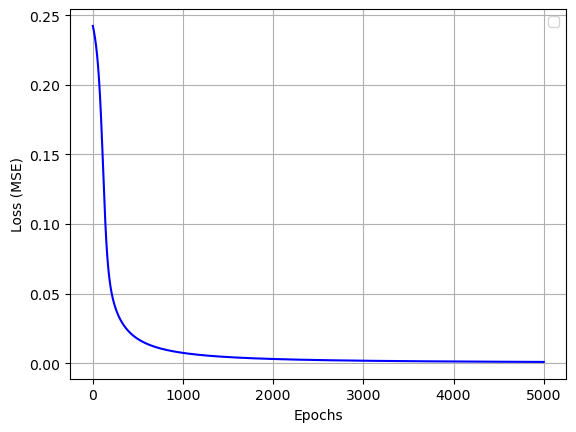

In [ ]:
# run with default model
model, final_error, loss_ot = run(print_epochs=False)
acc = accuracy(model.forward(X), Y)
print(f'Sigmoid Hidden Layer Activation\nFinal Error: {final_error}\nAccuracy: {acc}')

plt.plot(range(1, 5000 + 1), loss_ot, c='blue')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.grid(True)
plt.legend()
plt.show()

Sigmoid Hidden Layer Activation
Final Error: 0.0006904391271675963
Accuracy: 1.0


C:\Users\agile\AppData\Local\Temp\ipykernel_14560\3965136967.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


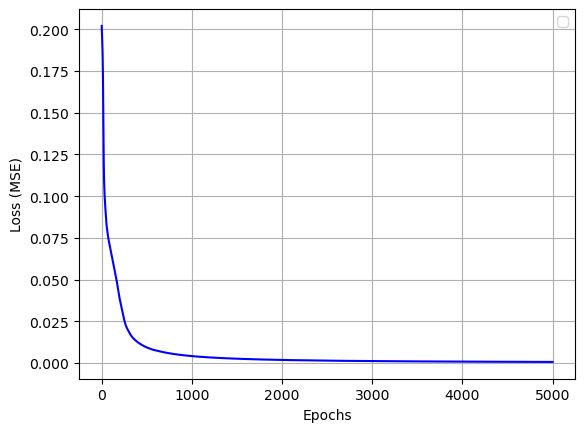

In [ ]:
# run with ReLU model
model, final_error, loss_ot = run(model=Sequential(layers=[Linear(5, 10), ReLU(), Linear(10, 1), Sigmoid()]), print_epochs=False)
acc = accuracy(model.forward(X), Y)
print(f'Sigmoid Hidden Layer Activation\nFinal Error: {final_error}\nAccuracy: {acc}')

plt.plot(range(1, 5000 + 1), loss_ot, c='blue')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.grid(True)
plt.legend()
plt.show()

From the observations, it is clear that the ReLU model performs better than the original one. The relevant observations are:
- Obseriving the final loss, the ReLU model loss is lower (0.00069 < 0.00099).
- Observing the loss overtime, the ReLU model reaches 0.050 loss sooner.

Thus, we can decisively say the ReLU activation for the hidden layer improves the performance for this problem.